# NYC Taxi Analysis

Source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Question: How can taxi companies position drivers to maximize ride volume? 

Problem: Where and when is taxi demand highest. 

## Initial Imports

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## Initial Data Loading

Only the first 3 months to get a feel for the data, then will make a cleaning/transforming functions to run on all the months. 

In [2]:
df_jan = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
df_feb = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet")
df_mar = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-03.parquet")

In [3]:
def display_info(df):
    print("Info")
    print("=" * 20)
    display(df.info())
    print("Describe")
    print("=" * 20)
    display(df.describe())
    print("Null Values")
    print("=" * 20)
    display(df.isna().sum())

In [4]:
display_info(df_jan)

Info
<class 'pandas.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float

None

Describe


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,3066766.000,3066766,3066766,2995023.000,3066766.000,2995023.000,3066766.000,3066766.000,3066766.000,3066766.000,3066766.000,3066766.000,3066766.000,3066766.000,3066766.000,3066766.000,2995023.000,2995023.000
mean,1.730,2023-01-17 00:22:26.288164,2023-01-17 00:38:06.427874,1.363,3.847,1.497,166.398,164.393,1.194,18.367,1.538,0.488,3.368,0.518,0.982,27.020,2.274,0.107
min,1.000,2008-12-31 23:01:42,2009-01-01 14:29:11,0.000,0.000,1.000,1.000,1.000,0.000,-900.000,-7.500,-0.500,-96.220,-65.000,-1.000,-751.000,-2.500,-1.250
25%,1.000,2023-01-09 16:21:57.250000,2023-01-09 16:37:06,1.000,1.060,1.000,132.000,114.000,1.000,8.600,0.000,0.500,1.000,0.000,1.000,15.400,2.500,0.000
50%,2.000,2023-01-17 08:42:29.500000,2023-01-17 08:58:30.500000,1.000,1.800,1.000,162.000,162.000,1.000,12.800,1.000,0.500,2.720,0.000,1.000,20.160,2.500,0.000
75%,2.000,2023-01-24 16:26:27,2023-01-24 16:42:49,1.000,3.330,1.000,234.000,234.000,1.000,20.500,2.500,0.500,4.200,0.000,1.000,28.700,2.500,0.000
max,2.000,2023-02-01 00:56:53,2023-02-02 09:28:47,9.000,258928.150,99.000,265.000,265.000,4.000,1160.100,12.500,53.160,380.800,196.990,1.000,1169.400,2.500,1.250
std,0.444,NaN,NaN,0.896,249.584,6.475,64.244,69.944,0.529,17.808,1.790,0.103,3.827,2.018,0.183,22.164,0.772,0.356


Null Values


VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
RatecodeID               71743
store_and_fwd_flag       71743
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     71743
airport_fee              71743
dtype: int64

In [5]:
display_info(df_feb)

Info
<class 'pandas.DataFrame'>
RangeIndex: 2913955 entries, 0 to 2913954
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float

None

Describe


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2913955.000,2913955,2913955,2837138.000,2913955.000,2837138.000,2913955.000,2913955.000,2913955.000,2913955.000,2913955.000,2913955.000,2913955.000,2913955.000,2913955.000,2913955.000,2837138.000,2837138.000
mean,1.731,2023-02-15 00:38:01.639923,2023-02-15 00:54:02.594499,1.353,3.868,1.515,166.257,164.232,1.183,18.220,1.560,0.488,3.385,0.511,0.981,26.898,2.285,0.097
min,1.000,2008-12-31 23:05:06,2008-12-31 23:31:24,0.000,0.000,1.000,1.000,1.000,0.000,-754.050,-7.500,-0.500,-93.000,-57.000,-1.000,-757.550,-2.500,-1.250
25%,1.000,2023-02-08 08:43:13,2023-02-08 08:59:34,1.000,1.060,1.000,132.000,113.000,1.000,8.600,0.000,0.500,1.000,0.000,1.000,15.480,2.500,0.000
50%,2.000,2023-02-14 22:33:21,2023-02-14 22:48:15,1.000,1.790,1.000,162.000,162.000,1.000,12.800,1.000,0.500,2.800,0.000,1.000,20.200,2.500,0.000
75%,2.000,2023-02-22 08:34:18,2023-02-22 08:50:06,1.000,3.300,1.000,234.000,234.000,1.000,20.300,2.500,0.500,4.200,0.000,1.000,28.700,2.500,0.000
max,6.000,2023-03-07 13:01:28,2023-03-07 13:11:17,9.000,335004.330,99.000,265.000,265.000,4.000,2203.100,20.800,4.000,482.900,109.900,1.000,2208.100,2.750,1.250
std,0.452,NaN,NaN,0.889,268.427,6.633,64.132,69.754,0.530,17.498,1.793,0.101,3.838,2.024,0.187,21.841,0.761,0.339


Null Values


VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          76817
trip_distance                0
RatecodeID               76817
store_and_fwd_flag       76817
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     76817
Airport_fee              76817
dtype: int64

In [6]:
display_info(df_mar)

Info
<class 'pandas.DataFrame'>
RangeIndex: 3403766 entries, 0 to 3403765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float

None

Describe


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,3403766.000,3403766,3403766,3316147.000,3403766.000,3316147.000,3403766.000,3403766.000,3403766.000,3403766.000,3403766.000,3403766.000,3403766.000,3403766.000,3403766.000,3403766.000,3316147.000,3316147.000
mean,1.725,2023-03-16 11:32:30.578784,2023-03-16 11:49:23.487819,1.351,3.904,1.624,165.454,164.100,1.187,18.908,1.629,0.487,3.495,0.567,0.981,27.803,2.275,0.104
min,1.000,2001-01-01 00:06:49,2001-01-01 14:13:51,0.000,0.000,1.000,1.000,1.000,0.000,-959.900,-7.500,-0.500,-80.000,-73.300,-1.000,-982.950,-2.500,-1.250
25%,1.000,2023-03-08 18:48:02,2023-03-08 19:04:47,1.000,1.050,1.000,132.000,114.000,1.000,9.300,0.000,0.500,1.000,0.000,1.000,15.700,2.500,0.000
50%,2.000,2023-03-16 12:18:33,2023-03-16 12:38:00,1.000,1.790,1.000,162.000,162.000,1.000,13.500,1.000,0.500,2.800,0.000,1.000,20.600,2.500,0.000
75%,2.000,2023-03-24 08:55:29.750000,2023-03-24 09:11:11.500000,1.000,3.380,1.000,233.000,234.000,1.000,21.200,2.500,0.500,4.340,0.000,1.000,29.760,2.500,0.000
max,6.000,2023-04-05 20:17:42,2023-04-05 20:35:28,9.000,216986.960,99.000,265.000,265.000,5.000,2100.000,13.750,4.000,984.300,177.000,1.000,2100.000,2.500,1.250
std,0.459,NaN,NaN,0.886,191.687,7.359,63.740,69.673,0.533,18.256,1.843,0.102,3.996,2.122,0.189,22.866,0.775,0.350


Null Values


VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          87619
trip_distance                0
RatecodeID               87619
store_and_fwd_flag       87619
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     87619
Airport_fee              87619
dtype: int64

Looking at the above information, the 3 dataframes are mostly similar:
- They all have the same 19 columns (with some formatting differences)
- The same 5 columns have missing data each time
- In those 5 columns, they all have the same amount of missing data (within their respective datasets)

## Next Steps 

Perform following data cleaning on January 2023 to make function for remaining months. 

1. Filter out data outside of the dataset's month &#x2714;
2. Check for patterns of missing data (Similar VendorIds, payment_types, etc.) &#x2714;
    - Check the data dictionary for assistance
3. ~~Impute congestion surcharge and airport fees with 0, as null values likely mean they were not congested and/or airport trips~~
    - Update: There are no missing values for surcharge or airport fee, as these were determined to be part of a pattern for the payment method.
4. Handle outliers and negative values for monetary columns (fares, fees, etc.) [ ] 

## Time Filtering

In [7]:
from pandas.tseries.offsets import MonthEnd, MonthBegin

In [8]:
jan_start = pd.Timestamp(
    year=2023,
    month=1,
    day=1
)
jan_start

Timestamp('2023-01-01 00:00:00')

In [9]:
jan_end = jan_start + MonthEnd(0)
jan_end

Timestamp('2023-01-31 00:00:00')

In [10]:
df_jan.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [11]:
df_jan[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].describe()

,tpep_pickup_datetime,tpep_dropoff_datetime
count,3066766,3066766
mean,2023-01-17 00:22:26.288164,2023-01-17 00:38:06.427874
min,2008-12-31 23:01:42,2009-01-01 14:29:11
25%,2023-01-09 16:21:57.250000,2023-01-09 16:37:06
50%,2023-01-17 08:42:29.500000,2023-01-17 08:58:30.500000
75%,2023-01-24 16:26:27,2023-01-24 16:42:49
max,2023-02-01 00:56:53,2023-02-02 09:28:47


In [12]:
# df_jan = 
df = df_jan[(df_jan['tpep_pickup_datetime'] >= jan_start) & (df_jan['tpep_pickup_datetime'] <= jan_end) & (df_jan['tpep_dropoff_datetime'] >= jan_start)]

In [13]:
df.shape

(2966346, 19)

In [14]:
df_jan.shape

(3066766, 19)

In [15]:
2966346  / 3066766

0.9672554084661171

In [16]:
df[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].describe()

,tpep_pickup_datetime,tpep_dropoff_datetime
count,2966346,2966346
mean,2023-01-16 12:35:55.136898,2023-01-16 12:51:34.193165
min,2023-01-01 00:00:00,2023-01-01 00:03:28
25%,2023-01-09 11:36:50.500000,2023-01-09 11:51:26.250000
50%,2023-01-16 15:40:55.500000,2023-01-16 15:57:06.500000
75%,2023-01-23 19:23:53.750000,2023-01-23 19:36:25
max,2023-01-30 23:59:58,2023-01-31 21:58:49


By removing the dates of pickup and dropoff that are outside of the month's first and last dates, we removed around 3% of data that would not be useful to our analysis. 

## Missing Data Patterns

In [17]:
missing_df = df[df.isna().sum(axis=1) > 0]

In [18]:
df.isna().sum()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          69382
trip_distance                0
RatecodeID               69382
store_and_fwd_flag       69382
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     69382
airport_fee              69382
dtype: int64

In [19]:
missing_df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,69382.000,69382,69382,0.000,69382.000,0.000,69382.000,69382.000,69382.000,69382.000,69382.000,69382.000,69382.000,69382.000,69382.000,69382.000,0.000,0.000
mean,1.655,2023-01-16 07:38:20.324349,2023-01-16 07:55:02.179153,NaN,19.253,NaN,164.592,161.287,0.000,20.857,0.233,0.499,3.739,0.448,0.997,29.178,NaN,NaN
min,1.000,2023-01-01 00:00:00,2023-01-01 00:08:00,NaN,0.000,NaN,1.000,1.000,0.000,-103.610,0.000,-0.500,-5.780,0.000,0.000,-89.100,NaN,NaN
25%,1.000,2023-01-09 06:33:31,2023-01-09 06:49:01,NaN,1.200,NaN,113.000,113.000,0.000,12.940,0.000,0.500,1.950,0.000,1.000,19.670,NaN,NaN
50%,2.000,2023-01-16 16:07:13.500000,2023-01-16 16:24:10,NaN,2.300,NaN,161.000,161.000,0.000,17.000,0.000,0.500,3.330,0.000,1.000,24.100,NaN,NaN
75%,2.000,2023-01-23 17:41:03.750000,2023-01-23 17:56:59.500000,NaN,4.197,NaN,236.000,234.000,0.000,24.697,0.000,0.500,4.780,0.000,1.000,33.010,NaN,NaN
max,2.000,2023-01-30 23:59:44,2023-01-31 00:12:01,NaN,258928.150,NaN,265.000,265.000,0.000,154.460,8.750,0.500,40.000,40.750,1.000,209.050,NaN,NaN
std,0.475,NaN,NaN,NaN,1590.439,NaN,71.180,70.637,0.000,13.608,0.792,0.019,3.185,1.834,0.046,17.131,NaN,NaN


In [20]:
df['payment_type'].value_counts()

payment_type
1    2330961
2     516266
0      69382
4      32313
3      17424
Name: count, dtype: int64

In [21]:
df['payment_type'].value_counts(normalize=True)

payment_type
1   0.786
2   0.174
0   0.023
4   0.011
3   0.006
Name: proportion, dtype: float64

There is only one notable consistency for the missing values. The `payment_type` column is all 0s (Flex Fare). Looking at the value counts for payment type, there are 69382 flex fare trips. There are also the exact same amount of NA values in each of the columns that are missing data. This tells us that when a trip is a flex fare trip, there is an issue in logging the `passenger_count`, `RateCodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `airport_fee`. 

Flex Fare trips make up 2.3% of the data. As such, I believe it is safe to remove those rows

In [22]:
df = df[df['payment_type'] != 0]

In [23]:
df.shape[0] / df_jan.shape[0]

0.9446315760641666

In [24]:
df.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

## Outliers for financial columns

In [25]:
financial_columns = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

In [26]:
df[financial_columns].describe()

,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,2896964.000,2896964.000,2896964.000,2896964.000,2896964.000,2896964.000,2896964.000,2896964.000,2896964.000
mean,18.325,1.563,0.488,3.359,0.524,0.982,26.984,2.274,0.108
std,17.935,1.793,0.105,3.847,2.029,0.186,22.321,0.773,0.357
min,-900.000,-7.500,-0.500,-96.220,-65.000,-1.000,-751.000,-2.500,-1.250
25%,8.600,0.000,0.500,1.000,0.000,1.000,15.400,2.500,0.000
50%,12.800,1.000,0.500,2.720,0.000,1.000,20.000,2.500,0.000
75%,19.800,2.500,0.500,4.140,0.000,1.000,28.560,2.500,0.000
max,1160.100,12.500,53.160,380.800,196.990,1.000,1169.400,2.500,1.250


We can see for all the financial columns, there are negative values. This could indicate an issue with the data collection, or it could just be refunded trips. Let's look at how many outliers there are for the fare amount and total amount. 

In [27]:
df[['fare_amount', 'total_amount']].describe()

,fare_amount,total_amount
count,2896964.000,2896964.000
mean,18.325,26.984
std,17.935,22.321
min,-900.000,-751.000
25%,8.600,15.400
50%,12.800,20.000
75%,19.800,28.560
max,1160.100,1169.400


We can see that there are large outliers on both the positive and negative sides. The outliers are close to the thousands or more, while 25th and 75th percentiles stay closer to 0, relatively. 

Let's take a look at a boxplot for both these columns. 

<Axes: xlabel='fare_amount'>

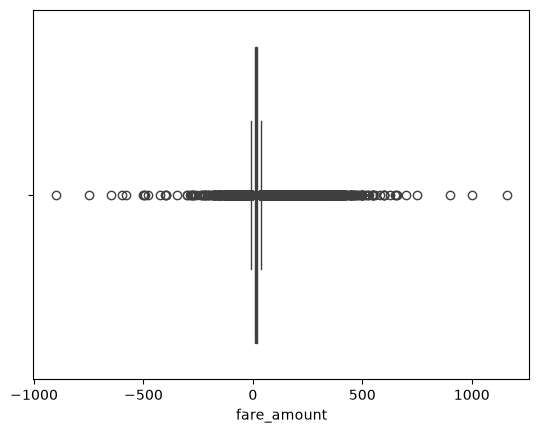

In [28]:
sns.boxplot(data=df, x='fare_amount')

<Axes: xlabel='total_amount'>

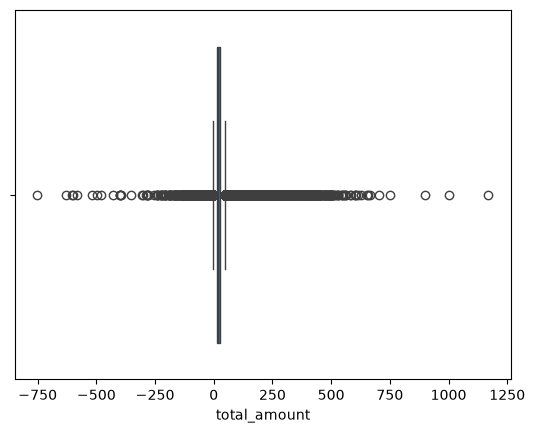

In [29]:
sns.boxplot(data=df, x='total_amount')

Looking at these boxplots, it is difficult to dicern the percentiles, but it is clear that the outliers are severely shrinking the box. Let's use scatterplots comapred with the trip distance to find anomalies. 

<Axes: xlabel='fare_amount', ylabel='trip_distance'>

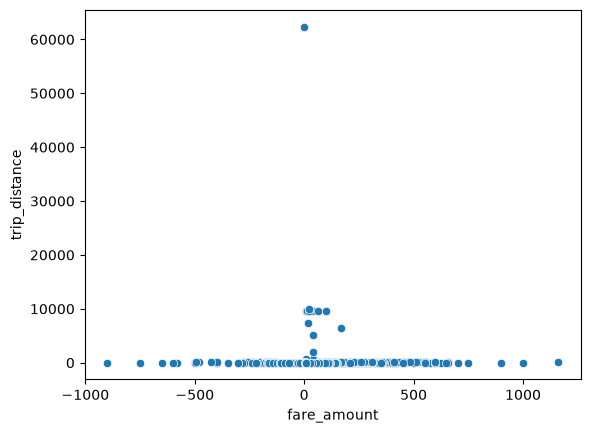

In [30]:
sns.scatterplot(data=df, x='fare_amount', y='trip_distance')

Hmmm... there seems to be some massive trips that are flattening the scatterplot. Let's remove those trips and see if that helps the visualization.

In [31]:
df['trip_distance'].describe()

count   2896964.000
mean          3.445
std          41.982
min           0.000
25%           1.060
50%           1.790
75%           3.320
max       62359.520
Name: trip_distance, dtype: float64

Let's assume that trips more than 100 miles are abnormal

In [32]:
under_100 = (df['trip_distance'] <= 100).sum()
above_100 = (df['trip_distance'] > 100).sum()

In [33]:
above_100

np.int64(35)

In [34]:
under_100

np.int64(2896929)

In [35]:
df = df[df['trip_distance'] <= 100]

<Axes: xlabel='fare_amount', ylabel='trip_distance'>

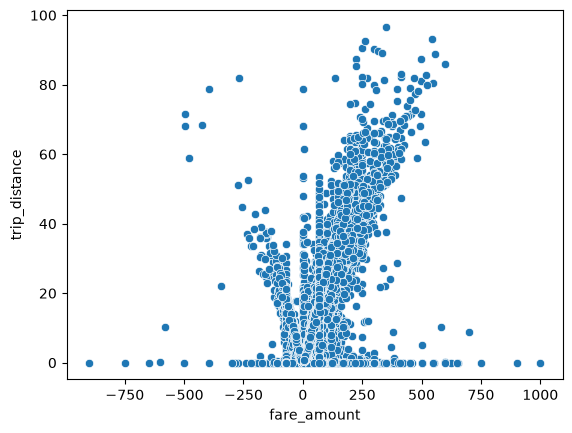

In [36]:
sns.scatterplot(data=df, x='fare_amount', y='trip_distance')

This shows us something interesting, which is that most are in the positive payments, but it also shows that there are alot of trips that have high fares (or very low negative fares), but a distance of nearly 0. It also shows some very long trips for almost no fare. Let's look at this in more detail by splitting it by the payment type

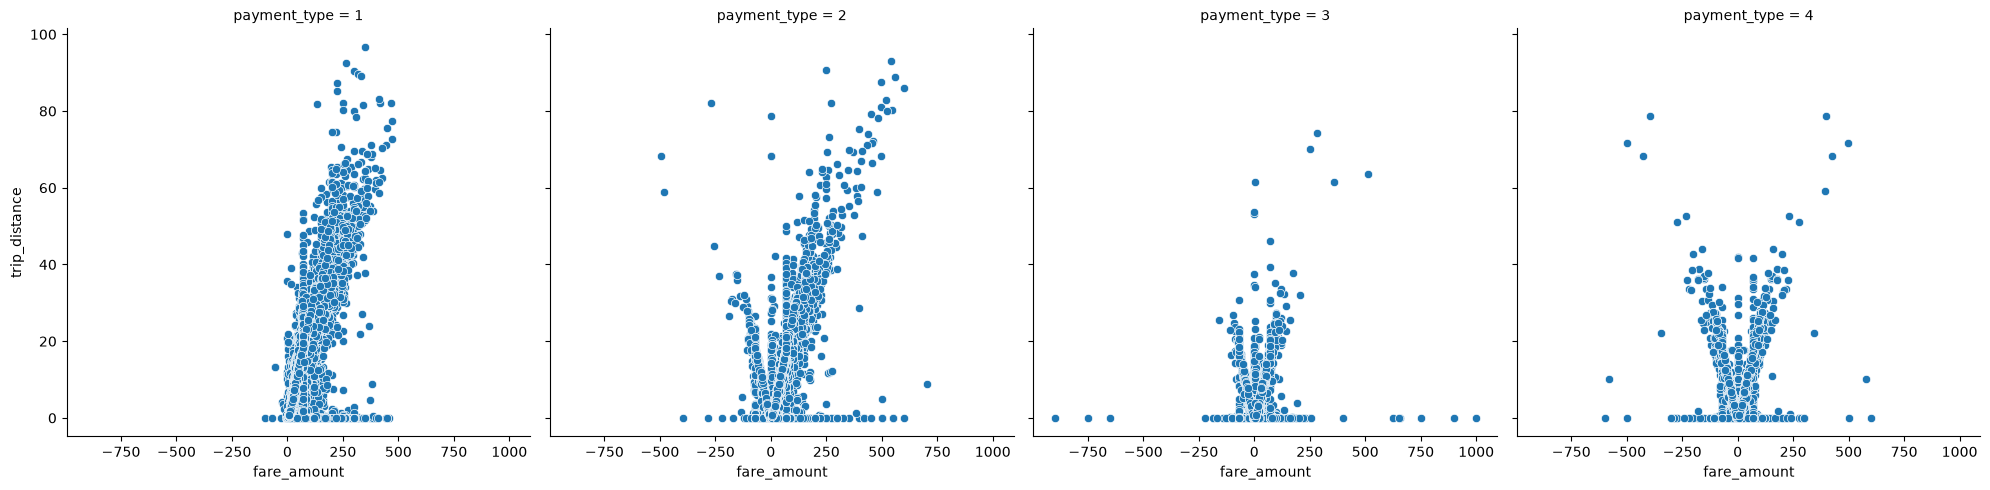

In [37]:
sns.relplot(data=df, x='fare_amount', y='trip_distance', col='payment_type')

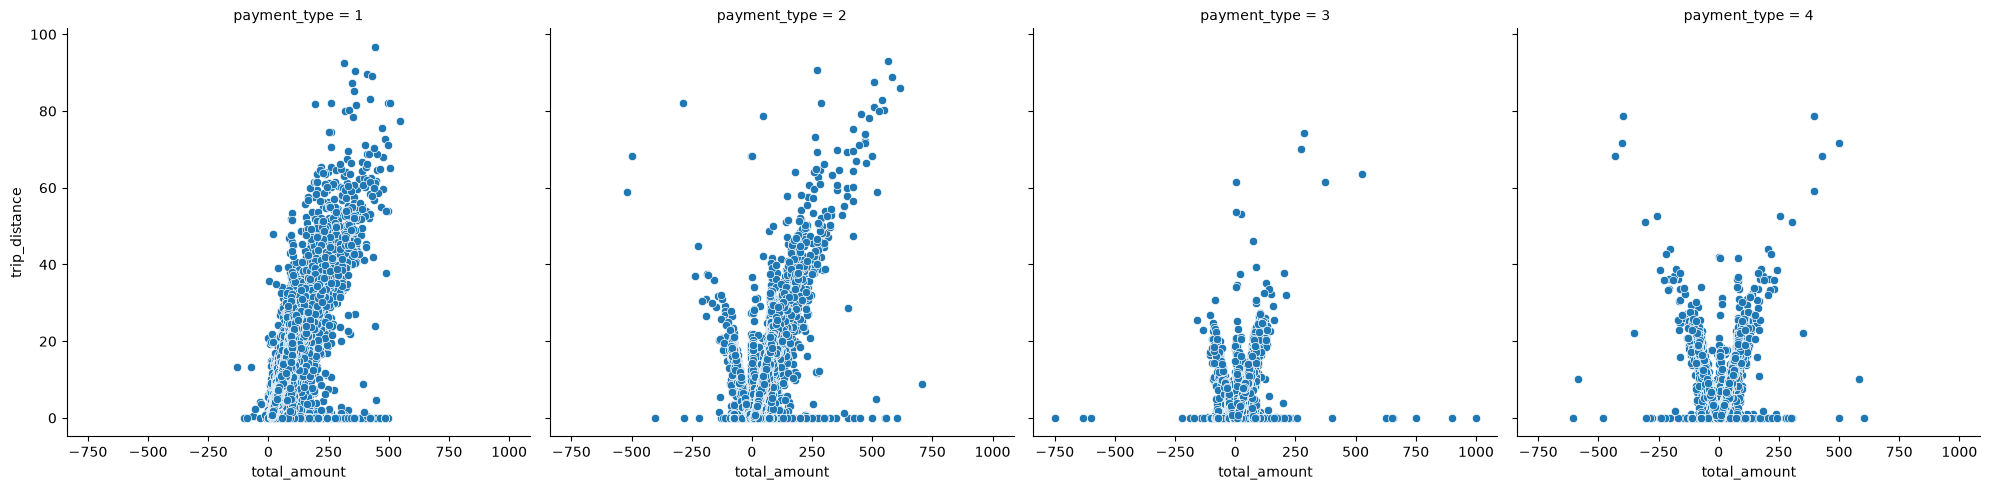

In [38]:
sns.relplot(data=df, x='total_amount', y='trip_distance', col='payment_type')

In [39]:
# df[df['payment_type'] == 3].head(30)

In [40]:
refunded_trips = df[df.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance'], keep=False)].sort_index()
refunded_trips.head(30)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
132,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.000,0.420,1.000,N,233,229,4,-5.100,-1.000,-0.500,0.000,0.000,-1.000,-10.100,-2.500,0.000
133,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.000,0.420,1.000,N,233,229,4,5.100,1.000,0.500,0.000,0.000,1.000,10.100,2.500,0.000
263,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.000,1.190,1.000,N,142,50,4,-9.300,-1.000,-0.500,0.000,0.000,-1.000,-14.300,-2.500,0.000
264,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.000,1.190,1.000,N,142,50,4,9.300,1.000,0.500,0.000,0.000,1.000,14.300,2.500,0.000
324,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.000,4.890,1.000,N,238,167,4,-25.400,-1.000,-0.500,0.000,0.000,-1.000,-30.400,-2.500,0.000
325,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.000,4.890,1.000,N,238,167,4,25.400,1.000,0.500,0.000,0.000,1.000,30.400,2.500,0.000
620,2,2023-01-01 00:06:39,2023-01-01 00:10:02,1.000,0.520,1.000,N,237,237,2,-5.100,-1.000,-0.500,0.000,0.000,-1.000,-10.100,-2.500,0.000
621,2,2023-01-01 00:06:39,2023-01-01 00:10:02,1.000,0.520,1.000,N,237,237,2,5.100,1.000,0.500,0.000,0.000,1.000,10.100,2.500,0.000
923,2,2023-01-01 00:34:39,2023-01-01 00:40:25,2.000,0.850,1.000,N,79,113,4,-7.200,-1.000,-0.500,0.000,0.000,-1.000,-12.200,-2.500,0.000
924,2,2023-01-01 00:34:39,2023-01-01 00:40:25,2.000,0.850,1.000,N,79,113,4,7.200,1.000,0.500,0.000,0.000,1.000,12.200,2.500,0.000


In [41]:
df['payment_type'].value_counts()

payment_type
1    2330940
2     516252
4      32313
3      17424
Name: count, dtype: int64

Looks like the negative values refer to refunds. We see this in the payment types 3 and 4 mostly, signfied by the near mirror images in the scatter plot. Further more, when searching for duplicates by hte timestamps and sorting, it seems to alternate between positive and negative amounts, showing the trip was refunded, and so a new row was logged. 

We will create new columns with teh absolute values of total and fare amounts, then make a new dataframe with just those duplicate columns, and remove them from the original dataset. 

In [42]:
df['abs_fare'] = df['fare_amount'].abs()

In [43]:
df['abs_total'] = df['total_amount'].abs()

In [44]:
df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.000,0.970,1.000,N,161,141,2,9.300,1.000,0.500,0.000,0.000,1.000,14.300,2.500,0.000,9.300,14.300
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.000,1.100,1.000,N,43,237,1,7.900,1.000,0.500,4.000,0.000,1.000,16.900,2.500,0.000,7.900,16.900


In [45]:
key_columns = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'passenger_count',
    'trip_distance',
    'PULocationID',
    'DOLocationID',
    'abs_fare',
    'abs_total'
]

In [46]:
refund_candidates = df[df.duplicated(subset=key_columns, keep=False)]
refund_candidates.head(6)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
132,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.000,0.420,1.000,N,233,229,4,-5.100,-1.000,-0.500,0.000,0.000,-1.000,-10.100,-2.500,0.000,5.100,10.100
133,2,2023-01-01 00:28:29,2023-01-01 00:31:03,1.000,0.420,1.000,N,233,229,4,5.100,1.000,0.500,0.000,0.000,1.000,10.100,2.500,0.000,5.100,10.100
263,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.000,1.190,1.000,N,142,50,4,-9.300,-1.000,-0.500,0.000,0.000,-1.000,-14.300,-2.500,0.000,9.300,14.300
264,2,2023-01-01 00:20:18,2023-01-01 00:27:56,2.000,1.190,1.000,N,142,50,4,9.300,1.000,0.500,0.000,0.000,1.000,14.300,2.500,0.000,9.300,14.300
324,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.000,4.890,1.000,N,238,167,4,-25.400,-1.000,-0.500,0.000,0.000,-1.000,-30.400,-2.500,0.000,25.400,30.400
325,2,2023-01-01 00:52:22,2023-01-01 01:14:03,1.000,4.890,1.000,N,238,167,4,25.400,1.000,0.500,0.000,0.000,1.000,30.400,2.500,0.000,25.400,30.400


In [47]:
df = df.drop_duplicates(subset=key_columns, keep=False)

We will keep the refund candidate table for further analysis later. Let's continue to clean up the original dataset, then create a function to clean any month's data as well as store that month's refund data. 

## Dropping Invalid Records

We will see how many rows have invalid records, such as:
- `trip_distance` < 0
- `total_amount` < 0
- `passenger_count` <= 0

In [48]:
df[df['trip_distance'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total


In [49]:
df[df['total_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
3622,2,2023-01-01 00:26:35,2023-01-01 00:34:31,1.000,1.410,1.000,N,90,170,4,-9.300,-1.000,-0.500,0.000,0.000,-1.000,-14.300,-2.500,0.000,9.300,14.300
3730,2,2023-01-01 00:35:23,2023-01-01 00:35:34,1.000,0.010,2.000,N,50,50,3,-70.000,0.000,-0.500,0.000,0.000,-1.000,-74.000,-2.500,0.000,70.000,74.000
4605,2,2023-01-01 00:04:11,2023-01-01 00:07:44,1.000,0.750,1.000,N,141,140,3,-5.800,-1.000,-0.500,0.000,0.000,-1.000,-10.800,-2.500,0.000,5.800,10.800
4609,2,2023-01-01 00:49:25,2023-01-01 00:56:05,2.000,0.600,1.000,N,249,114,3,-7.200,-1.000,-0.500,0.000,0.000,-1.000,-12.200,-2.500,0.000,7.200,12.200
7679,2,2023-01-01 01:13:55,2023-01-01 01:20:25,1.000,1.310,1.000,N,239,141,4,-9.300,-1.000,-0.500,0.000,0.000,-1.000,-14.300,-2.500,0.000,9.300,14.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895689,2,2023-01-30 23:22:48,2023-01-30 23:22:56,1.000,0.000,1.000,N,144,144,4,-3.000,-1.000,-0.500,0.000,0.000,-1.000,-8.000,-2.500,0.000,3.000,8.000
2896095,2,2023-01-30 23:38:33,2023-01-31 00:05:47,1.000,19.030,3.000,N,48,1,4,-89.500,-1.000,0.000,21.470,-15.850,-1.000,-85.880,0.000,0.000,89.500,85.880
2896678,2,2023-01-30 23:26:02,2023-01-30 23:54:43,1.000,21.210,2.000,N,132,87,2,-70.000,0.000,-0.500,0.000,0.000,-1.000,-75.250,-2.500,-1.250,70.000,75.250
2896701,2,2023-01-30 23:29:19,2023-01-30 23:33:30,1.000,2.810,1.000,N,132,132,4,-12.800,-1.000,-0.500,0.000,0.000,-1.000,-16.550,0.000,-1.250,12.800,16.550


In [50]:
df[df['passenger_count'] <= 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.000,1.900,1.000,N,138,7,1,12.100,7.250,0.500,0.000,0.000,1.000,20.850,0.000,1.250,12.100,20.850
485,1,2023-01-01 00:22:18,2023-01-01 00:28:17,0.000,1.300,1.000,N,170,107,1,8.600,3.500,0.500,2.700,0.000,1.000,16.300,2.500,0.000,8.600,16.300
486,1,2023-01-01 00:30:59,2023-01-01 00:34:46,0.000,1.000,1.000,N,79,107,1,6.500,3.500,0.500,2.300,0.000,1.000,13.800,2.500,0.000,6.500,13.800
487,1,2023-01-01 00:36:19,2023-01-01 00:43:46,0.000,2.300,1.000,N,107,232,1,11.400,3.500,0.500,3.250,0.000,1.000,19.650,2.500,0.000,11.400,19.650
488,1,2023-01-01 00:54:23,2023-01-01 01:08:18,0.000,2.100,1.000,N,79,231,2,12.800,3.500,0.500,0.000,0.000,1.000,17.800,2.500,0.000,12.800,17.800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2896465,1,2023-01-30 23:58:13,2023-01-31 00:00:45,0.000,0.400,1.000,N,125,249,1,4.400,3.500,0.500,1.850,0.000,1.000,11.250,2.500,0.000,4.400,11.250
2896775,1,2023-01-30 23:38:31,2023-01-30 23:46:08,0.000,1.400,1.000,N,170,264,1,10.000,3.500,0.500,0.000,0.000,1.000,15.000,2.500,0.000,10.000,15.000
2896887,1,2023-01-30 23:55:00,2023-01-31 00:31:33,0.000,28.800,1.000,N,132,66,2,105.900,2.250,0.500,0.000,0.000,1.000,109.650,0.000,1.250,105.900,109.650
2896903,1,2023-01-30 23:18:40,2023-01-30 23:51:00,0.000,18.500,2.000,N,132,48,1,70.000,3.750,0.500,12.270,6.550,1.000,94.070,2.500,1.250,70.000,94.070


In [51]:
(3477 / df.shape[0]) * 100

0.12178587052729395

In [52]:
(49518 / df.shape[0]) * 100

1.734424140572488

There are no rows that have negative trip values, but there are trips with negative total amounts which were not classified as refunds, adn there are rows with no passenger count. 

However, they only make up a combined 2% of the data, so we can safely drop these rows without affecting our analysis, as these may have just been incorrectly logged records, but we have no way of knowing for sure. 

We will keep audit tables of them for further analysis later if required. 

In [53]:
negative_trips = df[(df['total_amount'] < 0) | (df['fare_amount'] < 0)]
display(negative_trips.head())
negative_trips.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
3622,2,2023-01-01 00:26:35,2023-01-01 00:34:31,1.000,1.410,1.000,N,90,170,4,-9.300,-1.000,-0.500,0.000,0.000,-1.000,-14.300,-2.500,0.000,9.300,14.300
3730,2,2023-01-01 00:35:23,2023-01-01 00:35:34,1.000,0.010,2.000,N,50,50,3,-70.000,0.000,-0.500,0.000,0.000,-1.000,-74.000,-2.500,0.000,70.000,74.000
4605,2,2023-01-01 00:04:11,2023-01-01 00:07:44,1.000,0.750,1.000,N,141,140,3,-5.800,-1.000,-0.500,0.000,0.000,-1.000,-10.800,-2.500,0.000,5.800,10.800
4609,2,2023-01-01 00:49:25,2023-01-01 00:56:05,2.000,0.600,1.000,N,249,114,3,-7.200,-1.000,-0.500,0.000,0.000,-1.000,-12.200,-2.500,0.000,7.200,12.200
7679,2,2023-01-01 01:13:55,2023-01-01 01:20:25,1.000,1.310,1.000,N,239,141,4,-9.300,-1.000,-0.500,0.000,0.000,-1.000,-14.300,-2.500,0.000,9.300,14.300


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
count,3478.000,3478,3478,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000,3478.000
mean,2.000,2023-01-16 06:02:12.902242,2023-01-16 06:12:10.366302,1.295,2.734,1.170,163.579,157.540,3.347,-19.927,-0.918,-0.485,0.814,-0.355,-0.999,-24.005,-1.917,-0.218,19.927,24.005
min,1.000,2023-01-01 00:04:11,2023-01-01 00:07:44,1.000,0.000,1.000,1.000,1.000,1.000,-900.000,-7.500,-0.500,-11.110,-39.300,-1.000,-630.700,-2.500,-1.250,0.010,1.000
25%,2.000,2023-01-08 23:10:04.750000,2023-01-08 23:11:56.500000,1.000,0.370,1.000,132.000,100.000,2.000,-21.900,-1.000,-0.500,0.000,0.000,-1.000,-25.350,-2.500,0.000,6.500,10.500
50%,2.000,2023-01-15 23:53:35.500000,2023-01-15 23:57:34.500000,1.000,1.290,1.000,161.000,161.000,4.000,-11.400,-1.000,-0.500,0.000,0.000,-1.000,-15.700,-2.500,0.000,11.400,15.700
75%,2.000,2023-01-23 15:14:19.500000,2023-01-23 15:46:51.500000,1.000,3.140,1.000,231.000,230.000,4.000,-6.500,0.000,-0.500,0.000,0.000,-1.000,-10.500,-2.500,0.000,21.900,25.350
max,2.000,2023-01-30 23:38:33,2023-01-31 00:05:47,6.000,71.630,5.000,265.000,265.000,4.000,-0.010,0.000,0.500,270.300,0.000,1.000,1.000,0.000,0.000,900.000,630.700
std,0.017,NaN,NaN,0.668,4.344,0.642,65.512,75.703,0.867,33.199,1.326,0.087,5.823,1.921,0.034,30.528,1.057,0.475,33.199,30.528


In [54]:
zero_passenger = df[df['passenger_count'] <= 0]
display(zero_passenger.head())
zero_passenger.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.000,1.900,1.000,N,138,7,1,12.100,7.250,0.500,0.000,0.000,1.000,20.850,0.000,1.250,12.100,20.850
485,1,2023-01-01 00:22:18,2023-01-01 00:28:17,0.000,1.300,1.000,N,170,107,1,8.600,3.500,0.500,2.700,0.000,1.000,16.300,2.500,0.000,8.600,16.300
486,1,2023-01-01 00:30:59,2023-01-01 00:34:46,0.000,1.000,1.000,N,79,107,1,6.500,3.500,0.500,2.300,0.000,1.000,13.800,2.500,0.000,6.500,13.800
487,1,2023-01-01 00:36:19,2023-01-01 00:43:46,0.000,2.300,1.000,N,107,232,1,11.400,3.500,0.500,3.250,0.000,1.000,19.650,2.500,0.000,11.400,19.650
488,1,2023-01-01 00:54:23,2023-01-01 01:08:18,0.000,2.100,1.000,N,79,231,2,12.800,3.500,0.500,0.000,0.000,1.000,17.800,2.500,0.000,12.800,17.800


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
count,49518.000,49518,49518,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000,49518.000
mean,1.003,2023-01-16 11:56:31.823781,2023-01-16 12:09:40.596874,0.000,2.772,1.139,168.485,166.842,1.254,16.285,3.200,0.497,2.873,0.338,0.996,24.192,2.321,0.072,16.285,24.192
min,1.000,2023-01-01 00:03:48,2023-01-01 00:07:23,0.000,0.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,2023-01-09 10:16:51.250000,2023-01-09 10:33:10.500000,0.000,1.000,1.000,132.000,125.000,1.000,7.900,2.500,0.500,0.000,0.000,1.000,14.600,2.500,0.000,7.900,14.600
50%,1.000,2023-01-16 14:58:17.500000,2023-01-16 15:08:32.500000,0.000,1.600,1.000,162.000,162.000,1.000,11.400,2.500,0.500,2.460,0.000,1.000,18.750,2.500,0.000,11.400,18.750
75%,1.000,2023-01-23 19:23:06.750000,2023-01-23 19:32:40.250000,0.000,2.800,1.000,236.000,236.000,1.000,17.700,3.500,0.500,3.750,0.000,1.000,25.500,2.500,0.000,17.700,25.500
max,2.000,2023-01-30 23:59:40,2023-01-31 00:31:33,0.000,74.400,99.000,265.000,265.000,4.000,655.350,11.250,4.000,140.000,92.750,1.000,656.850,2.500,1.250,655.350,656.850
std,0.057,NaN,NaN,0.000,3.737,2.777,63.715,69.068,0.524,16.181,1.449,0.053,3.334,1.701,0.058,19.351,0.644,0.290,16.181,19.351


In [55]:
df = df[(df['total_amount'] >= 0) & (df['fare_amount'] >= 0) & (df['passenger_count'] > 0)]

In [56]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,abs_fare,abs_total
count,2802015.000,2802015,2802015,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000,2802015.000
mean,1.741,2023-01-16 12:49:22.802829,2023-01-16 13:05:07.382481,1.390,3.399,1.506,166.372,164.429,1.189,18.680,1.561,0.496,3.421,0.536,0.999,27.498,2.312,0.111,18.680,27.498
min,1.000,2023-01-01 00:00:05,2023-01-01 00:03:28,1.000,0.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,2023-01-09 11:55:40,2023-01-09 12:11:18.500000,1.000,1.080,1.000,132.000,114.000,1.000,8.600,0.000,0.500,1.000,0.000,1.000,15.480,2.500,0.000,8.600,15.480
50%,2.000,2023-01-16 15:45:33,2023-01-16 16:01:53,1.000,1.800,1.000,162.000,162.000,1.000,12.800,1.000,0.500,2.800,0.000,1.000,20.160,2.500,0.000,12.800,20.160
75%,2.000,2023-01-23 19:28:44,2023-01-23 19:41:41,1.000,3.340,1.000,234.000,234.000,1.000,20.500,2.500,0.500,4.200,0.000,1.000,28.800,2.500,0.000,20.500,28.800
max,2.000,2023-01-30 23:59:58,2023-01-31 21:58:49,9.000,96.700,99.000,265.000,265.000,4.000,999.000,12.500,53.160,380.800,196.990,1.000,1000.000,2.500,1.250,999.000,1000.000
std,0.438,NaN,NaN,0.890,4.423,6.541,64.126,69.980,0.413,17.448,1.776,0.054,3.855,2.031,0.033,21.761,0.659,0.355,17.448,21.761


In [58]:
df.shape

(2802015, 21)

In [62]:
df_jan.shape

(3066766, 19)

In [65]:
(1 - (df.shape[0] / df_jan.shape[0])) * 100

8.63290515155053

In total, cleaning the data removed approximately 8.63% of the original data for the month of January. After cleaning the data, the passenger counts are 1 or more, there are no negative amounts for currency columns, the longest trip is ~97 miles (originally, it was hundreds of thousands of miles), etc.

Next, we will create a function to do all this cleaning in one step that can be reused on multiple months to create clean datasets for each month, as well as audit tables for each month to investigate refunds, negative trips, and zero passenger rides. 

#### Old Code Below

In [57]:
# print(f"Total Amount under 0: {df[df['total_amount'] < 0].shape[0]}")
# print(f"Fare Amount Amount under 0: {df[df['fare_amount'] < 0].shape[0]}")

# refunded_trips.shape[0] / 2

# refunded_trips[refunded_trips['fare_amount'] < 0].shape[0]

# refunded_trips[refunded_trips['fare_amount'] >= 0].shape[0]



# pos = df[df.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance'], keep='first')].sort_index()
# pos.head(10)

# neg = df[df.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance'], keep='last')].sort_index()
# neg.head(10)

# pos[pos['fare_amount'] < 0]

# neg[neg['fare_amount'] > 0]

# test_row = df.loc[20539]

# df[(df['tpep_pickup_datetime'] == test_row.tpep_pickup_datetime) & (df['tpep_dropoff_datetime'] == test_row.tpep_dropoff_datetime)] 